In [8]:
6100/500

12.2

In [94]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import Point 
import sys
import os 
import rasterio
from sklearn.utils import resample
import logging

# -------------------- PATHS AND CONSTANTS --------------------

# Define directories for data and outputs
run_dir = '/Volumes/im3/projects/cerf/exp_b_paper'
exp_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/experiment_runs/run_110824'
exp_data_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/models/cerf/data'
gridcerf_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/external_data/gridcerf_2.1'

# data_dir = os.path.join(run_dir, 'data')
# output_dir = os.path.join(run_dir, 'output_100825_2')

data_dir = os.path.join(run_dir, 'data')
output_dir = os.path.join(run_dir, 'output')
west_lmp_raster_fn = os.path.join(data_dir, 'west_lmp_polygons.tif')
west_state_raster_fn = os.path.join(data_dir, 'west_state_raster.tif')
transmission_cost_raster_fn = os.path.join(data_dir, 'transmission_cost_raster_west.tif')
gas_pipeline_cost_raster_fn = os.path.join(data_dir, 'gas_pipeline_cost_raster_west.tif')
power_plant_file = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')

# List of scenario names
scenario_list = [
    'rcp45cooler_ssp3',
    # 'rcp45cooler_ssp5',
    # 'rcp85cooler_ssp3',
    # 'rcp85cooler_ssp5',
    # 'rcp45hotter_ssp3',
    # 'rcp45hotter_ssp5',
    # 'rcp85hotter_ssp3',
    # 'rcp85hotter_ssp5'
]

# Mapping of state FIPS codes to state names
state_fips = {
    4: 'arizona',  
    6: 'california',  
    8: 'colorado', 
    16: 'idaho',
    30: 'montana',
    32: 'nevada', 
    35: 'new_mexico', 
    41: 'oregon', 
    49: 'utah', 
    53: 'washington',
    56: 'wyoming'
}

# Mapping of technology names to analysis paths
analysis_path_dict = {
    # 'gridcerf_gas_cc_no-ccs_dry': 'gas/gridcerf_gas_cc_no-ccs_dry',                                  
    # 'gridcerf_gas_cc_no-ccs_recirculating': 'gas/gridcerf_gas_cc_no-ccs_recirculating',    
    # 'gridcerf_gas_turbine_no-ccs_no-cooling': 'gas/gridcerf_gas_turbine_no-ccs_no-cooling',    
    'gridcerf_solar_pv_centralized_no-cooling': 'solar/gridcerf_solar_pv_centralized_no-cooling_6cf',    
    # 'gridcerf_wind_onshore_hubheight100_no-cooling': 'wind/gridcerf_wind_onshore_hubheight100_no-cooling_5cf', 
    # 'gridcerf_wind_onshore_hubheight120_no-cooling': 'wind/gridcerf_wind_onshore_hubheight120_no-cooling_5cf',
    # 'gridcerf_wind_onshore_hubheight140_no-cooling': 'wind/gridcerf_wind_onshore_hubheight140_no-cooling_5cf',
    # 'gridcerf_wind_onshore_hubheight80_no-cooling': 'wind/gridcerf_wind_onshore_hubheight100_no-cooling_5cf',
}

# Inverted mapping for state names to FIPS codes
inverted_state_fips = {value: key for key, value in state_fips.items()}

# -------------------- DATA PREPARATION FUNCTIONS --------------------

def get_feature_gdf(power_plant_file):
    """
    Load and process the power plant GeoDataFrame, extracting relevant features and scenario info.
    """
    gdf = gpd.read_file(power_plant_file)

    logging.info("Processing geodataframe...")
    gdf_feature = gdf[gdf.cerf_sited == True][[
        'scenario', 'region_name', 'tech_name', 'tech_simple', 'xcoord', 'ycoord',
        'generation_type', 'sited_year', 'interconnection_cost_usd_per_year', 
        'capacity_factor_fraction', 'geometry'
    ]].copy()
    # Extract sub-type, ccs, and cooling type from tech_name
    gdf_feature['sub_type'] = gdf_feature['tech_name'].str.split("_", expand=True)[2]
    gdf_feature['ccs'] = gdf_feature['tech_name'].str.split("_", expand=True)[3]
    gdf_feature['cooling_type'] = gdf_feature['tech_name'].str.split("_", expand=True)[4]
    # Adjust for wind generation
    gdf_feature['sub_type'] = np.where(gdf_feature.generation_type == 'Wind', gdf_feature['ccs'], gdf_feature['sub_type'])
    gdf_feature['ccs'] = np.where(gdf_feature.generation_type == 'Wind', 'no-ccs', gdf_feature['ccs'])
    # Extract scenario parameters
    gdf_feature['rcp'] = np.where(gdf_feature.scenario.str.contains('rcp45'), 45, 85)
    gdf_feature['ssp'] = np.where(gdf_feature.scenario.str.contains('ssp3'), 3, 5)
    gdf_feature['climate'] = np.where(gdf_feature.scenario.str.contains('cooler'), 'cooler', 'hotter')

    return gdf_feature

def get_cf_df(gdf_feature):
    """
    Calculate average capacity factor by technology and region.
    """
    cfdf = gdf_feature.copy()
    cfdf['tech_simple'] = np.where(cfdf['tech_simple'] == 'Gas CC (CCS)', 'Gas CC', cfdf['tech_simple'])
    gen_list = ['Gas CC', 'Gas CT', 'Solar PV', 'Wind (Onshore)']
    cfdf = cfdf[cfdf['tech_simple'].isin(gen_list)]
    cfdf = cfdf[['scenario', 'region_name', 'tech_simple', 'sited_year', 'capacity_factor_fraction']].groupby(
        ['region_name', 'sited_year', 'scenario', 'tech_simple'], as_index=False).mean()
    return cfdf

def get_cf_bin(capacity_factor_fraction):
    """
    Get the correct start and through index values to average over for calculating LMP.
    """
    if capacity_factor_fraction == 1.0:
        start_index = 0
        through_index = 8760
    elif capacity_factor_fraction >= 0.5:
        start_index = int(np.ceil(8760 * (1 - capacity_factor_fraction)))
        through_index = 8760
    elif capacity_factor_fraction == 0.0:
        msg = f"The capacity factor provided `{capacity_factor_fraction}` is outside the bounds of 0.0 through 1.0"
        raise ValueError(msg)
    else:
        start_index = 0
        through_index = int(np.ceil(8760 * capacity_factor_fraction))
    return start_index, through_index

def pivot_lmp_file(input_lmp_df):
    """
    Pivot the LMP DataFrame to wide format (hours x buses).
    """
    buses_str = [*input_lmp_df['Bus'].unique()]
    buses_int = [int(i[4:]) for i in buses_str]
    number_of_nodes = len(buses_int)
    hour_nums = [*range(1,8761)]
    number_of_hours = len(hour_nums)
    Organized_LMP = pd.DataFrame(np.zeros((number_of_hours,number_of_nodes)),columns=buses_str)
    for bus in buses_str:
        Bus_LMPs = input_lmp_df.loc[input_lmp_df['Bus']==bus]['Value'].values
        Organized_LMP.loc[:,bus] = Bus_LMPs
    Organized_LMP.columns = buses_int
    Organized_LMP.insert(loc=0, column='hour', value=hour_nums)
    return Organized_LMP

def get_lmp_dict(wide_lmp_df, capacity_factor_fraction, operational_hours_file=None):
    """
    Create a dictionary of LMP values for each power zone based on tech capacity factor or operational hours.
    """
    if operational_hours_file is None:
        # Use capacity factor bin method
        start_index, through_index = get_cf_bin(capacity_factor_fraction)
        # Sort by descending LMP for each zone
        for j in wide_lmp_df.columns:
            wide_lmp_df[j] = wide_lmp_df[j].sort_values(ascending=False).values
        # Average over the relevant hours
        lmp_dict = wide_lmp_df.iloc[start_index:through_index].mean(axis=0).to_dict()
    else:
        # Use operational hours file
        operational_hours_df = pd.read_csv(operational_hours_file)
        operational_hours_index_list = operational_hours_df[operational_hours_df.operational == 1].index.to_list()
        lmp_dict = wide_lmp_df.iloc[operational_hours_index_list].mean(axis=0).to_dict()
    return lmp_dict

def get_tech_lmp_array(scenario, timestep, subset_df, tech_simple, west_lmp_raster_fn, west_state_raster_fn):
    """
    For a given scenario and timestep, create an array of LMP values for each grid cell, 
    mapped by region and technology.
    """
    with rasterio.open(west_lmp_raster_fn) as src:
        lmp_array = src.read(1)
    with rasterio.open(west_state_raster_fn) as src:
        state_array = src.read(1)
    go_dir = os.path.join(exp_dir, scenario, f'go/output/native_output/{timestep}/duals')
    for i in os.listdir(go_dir):
        if i.startswith(f'duals_{timestep-5}PI'):
            # Read in LMP DataFrame
            fn = os.path.join(go_dir, i)
            long_lmp_df = pd.read_parquet(fn, engine="fastparquet")
            lmp_df = pivot_lmp_file(input_lmp_df=long_lmp_df)
            lmp_df = lmp_df.drop('hour', axis=1)
            # Initialize array for this technology
            tech_array = np.zeros_like(lmp_array)
            for region in subset_df.region_name.unique():
                # Get regional capacity factor
                cf_region = subset_df[subset_df.region_name == region]['capacity_factor_fraction'].iloc[0]
                # Use operational hours file for renewables
                if tech_simple in ['Solar PV', 'Wind (Onshore)']:
                    tech_short = 'solar' if tech_simple == 'Solar PV' else 'wind'
                    operational_hours_file = os.path.join(
                        exp_data_dir, 'cerf_setup_files', 'renewable_capacity_factor_files',
                        f'{region}_{tech_short}_operational_hours.csv'
                    )
                else:
                    operational_hours_file = None
                # Get LMP dictionary for region/tech
                lmp_dict = get_lmp_dict(
                    wide_lmp_df=lmp_df, 
                    capacity_factor_fraction=cf_region, 
                    operational_hours_file=operational_hours_file
                )
                lmp_dict[0] = np.nan  # Set nodata value
                dict_map_func = np.vectorize(lmp_dict.get)
                tech_lmp_arr = dict_map_func(lmp_array)
                region_id = inverted_state_fips[region]
                region_mask = state_array == region_id
                tech_lmp_arr = tech_lmp_arr * region_mask
                # Add to composite tech array
                tech_array += tech_lmp_arr
        else:
            pass
    return tech_array

def create_full_grid_cell_array(west_lmp_raster_fn):
    """
    Create a GeoDataFrame of all grid cells in the study area, with coordinates and geometry.
    """
    logging.info("Creating geodataframe of all grid cells...")
    with rasterio.open(west_lmp_raster_fn) as src:
        transform = src.transform
        width = src.width
        height = src.height
        # Get all row/col indices
        rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
        xs, ys = rasterio.transform.xy(transform, rows, cols)
        xs = np.array(xs).flatten()
        ys = np.array(ys).flatten()
        rs = np.array(rows).flatten()
        cs = np.array(cols).flatten()
        all_coords = pd.DataFrame({'xcoord': xs, 'ycoord': ys, 'row':rs, 'col':cs})
        all_coords['geometry'] = [Point(x, y) for x, y in zip(xs, ys)]
        all_coord_gdf = gpd.GeoDataFrame(all_coords, geometry='geometry', crs='ESRI:102003')
        all_coord_gdf.geometry = all_coord_gdf.geometry.buffer(500, cap_style='square')
    # Return coordinates and GeoDataFrame
    coords = [(x,y) for x, y in zip(all_coord_gdf['xcoord'], all_coord_gdf['ycoord'])]
    return coords, all_coord_gdf

def collect_single_run_data(transmission_cost_raster_fn,
                            gas_pipeline_cost_raster_fn,
                            west_state_raster_fn,
                            coords=None):
    """
    Collect interconnection cost and region information for each grid cell in the study area.
    """
    logging.info("Collecting interconnection cost information...")
    # Transmission cost
    with rasterio.open(transmission_cost_raster_fn) as src:
        transmission_cost_at_points = [int(i[0]) for i in src.sample(coords)]      
    # Gas pipeline cost
    with rasterio.open(gas_pipeline_cost_raster_fn) as src:
        gas_pipeline_cost_at_points = [int(i[0]) for i in src.sample(coords)]      
    logging.info("Collecting state information...")
    # Region ID (state)
    with rasterio.open(west_state_raster_fn) as src:
        region_at_points = [int(i[0]) for i in src.sample(coords)]  
    return transmission_cost_at_points, gas_pipeline_cost_at_points, region_at_points

def collect_analysis_data(rcp,
                          ssp,
                          climate,
                          tech, 
                          gdf_feature,
                          all_coord_gdf, 
                          coords,
                          transmission_cost_at_points,
                          gas_pipeline_cost_at_points,
                          region_at_points,
                          state_fips=state_fips,
                          analysis_path_dict=analysis_path_dict, 
                          gridcerf_dir=gridcerf_dir):
    """
    For each scenario combination, build a dataframe of all grid cells in the study area and identify:
    - Whether it saw a siting of the given technology
    - Suitability of the grid cell
    - Locational marginal price (LMP) for the grid cell and timestep
    - Interconnection cost for the grid cell

    Filters out unsuitable grid cells and those in states with no development.
    Returns a dataframe of all sitings and non-sitings for all scenarios for the given timestep and technology.
    """
    # Map full technology name to tech_simple
    tech_simple_dict = gdf_feature.drop_duplicates(subset='tech_name')[['tech_name', 'tech_simple']].set_index('tech_name').to_dict()['tech_simple']
    gdf_list = []
    for timestep in [2040]:#range(2020, 2056, 5):       
        logging.info(f"Collecting data for timestep {timestep} and technology {tech}")     
        tech_simple = tech_simple_dict[tech]
        tech_path = analysis_path_dict[tech]
        suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')

        # Filter sited plants for this scenario/timestep/tech
        gdf_feature_subset = gdf_feature[
            (gdf_feature.rcp == rcp) & 
            (gdf_feature.ssp == ssp) & 
            (gdf_feature.climate == climate) & 
            (gdf_feature.tech_name == tech) &
            (gdf_feature.sited_year == timestep)
        ].copy()

        # assign sited = 1 for sitings
        gdf_feature_subset['sited'] = 1

        # Spatial join: all grid cells with sited data to get dataframe of sited and non-sited cells
        g = gpd.sjoin(all_coord_gdf, gdf_feature_subset[['sited', 'geometry']], how='left')

        # Fill in missing parameters for non-sited cells
        g['rcp'] = rcp
        g['ssp'] = ssp
        g['climate'] = climate
        g['tech_name'] = tech
        g['sited_year'] = timestep
        g['sited'] = g['sited'].fillna(0)
        g['region_id'] = region_at_points
        g['region_name'] = g['region_id'].map(state_fips)

        # Collect suitability
        g = g.reset_index(drop=True)
        subset_coords = [(x,y) for x, y in zip(g['xcoord'], g['ycoord'])]
        with rasterio.open(suit_fn) as src:
            suitability_at_points = [int(i[0]) for i in src.sample(subset_coords)]       
        g['suitability'] = suitability_at_points
        g['suitability'] = np.where(g['sited'] == 1, 0, g['suitability'])  # Ensure sitings are suitable
        
        # Collect interconnection cost
        g['transmission_cost'] =  transmission_cost_at_points
        g['pipeline_cost'] =  gas_pipeline_cost_at_points
        if 'gas' in tech:
            g['interconnection_cost'] = g['transmission_cost'] + g['pipeline_cost']
        else:
            g['interconnection_cost'] = g['transmission_cost']
        
        # Collect LMP information by row, col in dataframe
        lmp_array = get_tech_lmp_array(
            scenario=scenario, 
            timestep=timestep, 
            subset_df=gdf_feature_subset, 
            tech_simple=tech_simple, 
            west_lmp_raster_fn=west_lmp_raster_fn, 
            west_state_raster_fn=west_state_raster_fn
        )
        g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
        # Drop unsuitable or missing LMP rows
        g = g[g.suitability == 0]
        g = g[~g.lmp.isna()]

        # only keep grid cells in states with sitings
        g = g[g.region_name.isin(gdf_feature_subset.region_name.unique())] 
        gdf_list.append(g)
    # Concatenate all dataframes for all timesteps
    gdf_list = [g.reset_index(drop=True) for g in gdf_list]
    timestep_df = pd.concat(gdf_list)
    # Categorical encoding for scenario variables
    timestep_df['rcp'] = np.where(timestep_df['rcp'] == 45, 0, 1)
    timestep_df['ssp'] = np.where(timestep_df['ssp'] == 3, 0, 1)
    timestep_df['climate'] = np.where(timestep_df['climate'] == 'cooler', 0, 1)
    return timestep_df

def create_balanced_dataset(df, resample_ratio=2):
    """
    Create a balanced dataset by resampling the data to have equal numbers of sitings and non-sitings within each state and timestep that saw sitings.
    """
    balanced_dfs = []   
    for region in df.region_name.unique():
        region_df = df[df['region_name'] == region].copy()
        for timestep in region_df.sited_year.unique():
            
            region_timestep_df = region_df[region_df['sited_year'] == timestep]

            # collect sitings and non-sitings
            region_sitings = region_timestep_df[region_timestep_df['sited'] == 1]
            region_non_sitings = region_timestep_df[region_timestep_df['sited'] == 0]

            # Resample non-sitings to match the number of sitings
            non_sitings_resampled = resample(region_non_sitings, n_samples=len(region_sitings)*resample_ratio, random_state=42)
            # Concatenate sitings and resampled non-sitings
            balanced_df = pd.concat([region_sitings, non_sitings_resampled])

            balanced_df.reset_index(drop=True)
            balanced_dfs.append(balanced_df)

    return pd.concat(balanced_dfs)

def balance_and_save(df, output_path, resample_ratio=2):
    """Balance the dataset and save it to a parquet file."""
    logging.info("Balancing dataset...")
    balanced_df = create_balanced_dataset(df, resample_ratio)
    balanced_df.to_csv(output_path, index=False)
    logging.info(f"Balanced dataset saved to {output_path}")
    return None


tech_list =[
#'gridcerf_gas_cc_no-ccs_dry',
# 'gridcerf_gas_cc_no-ccs_recirculating',
# 'gridcerf_gas_turbine_no-ccs_no-cooling',
'gridcerf_solar_pv_centralized_no-cooling',
# 'gridcerf_wind_onshore_hubheight100_no-cooling',
# 'gridcerf_wind_onshore_hubheight120_no-cooling',
# 'gridcerf_wind_onshore_hubheight140_no-cooling',
# 'gridcerf_wind_onshore_hubheight80_no-cooling'
]
tech = tech_list[0]

west_lmp_raster_fn = os.path.join(data_dir, 'west_lmp_polygons.tif')
west_state_raster_fn = os.path.join(data_dir, 'west_state_raster.tif')
transmission_cost_raster_fn = os.path.join(data_dir, 'transmission_cost_raster_west.tif')
gas_pipeline_cost_raster_fn = os.path.join(data_dir, 'gas_pipeline_cost_raster_west.tif')
power_plant_file = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')

# sited power plants
gdf_feature = get_feature_gdf(power_plant_file=power_plant_file)

cfdf = get_cf_df(gdf_feature=gdf_feature)
# coords, all_coord_gdf = create_full_grid_cell_array(west_lmp_raster_fn=west_lmp_raster_fn)
# transmission_cost_at_points, gas_pipeline_cost_at_points, region_at_points = collect_single_run_data(transmission_cost_raster_fn,
#                                                                                                      gas_pipeline_cost_raster_fn,
#                                                                                                         west_state_raster_fn,
#                                                                                                             coords=coords)

# geodatframe of grid
all_coord_gdf = gpd.read_file(os.path.join(data_dir, 'state_all_coord_w_interconnection.geojson'))


#coords = [(x,y) for x, y in zip(all_coord_gdf['xcoord'], all_coord_gdf['ycoord'])]
# transmission_cost_at_points = all_coord_gdf['transmission_cost'].tolist()
# gas_pipeline_cost_at_points = all_coord_gdf['pipeline_cost'].tolist()
#region_at_points = all_coord_gdf['region_id'].tolist()



KeyError: 'region_id'

In [100]:
all_coord_gdf = all_coord_gdf.set_crs('ESRI:102003', allow_override=True)

In [101]:
print('Collecting data for technology:', tech)
    
# Run the function in parallel and collect the results in a list  
for rcp in [45]:#, 85]:
    for ssp in [3]:#, 5]:
        for climate in ['cooler']:#, 'cooler']:#,]:
            scenario=f'rcp{rcp}{climate}_ssp{ssp}'

            # results = collect_analysis_data(rcp=rcp,
            #                                 ssp=ssp,
            #                                 climate=climate,
            #                                 tech=tech, 
            #                                 gdf_feature=gdf_feature, 
            #                                 all_coord_gdf=all_coord_gdf, 
            #                                 coords=coords,
            #                                 transmission_cost_at_points=transmission_cost_at_points,
            #                                 gas_pipeline_cost_at_points= gas_pipeline_cost_at_points,
            #                                 region_at_points= region_at_points,)

            tech_simple_dict = gdf_feature.drop_duplicates(subset='tech_name')[['tech_name', 'tech_simple']].set_index('tech_name').to_dict()['tech_simple']
            gdf_list = []
            for timestep in [2045]:#range(2020, 2056, 5):       
                tech_simple = tech_simple_dict[tech]
                tech_path = analysis_path_dict[tech]
                suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')
        
                # Filter sited plants for this scenario/timestep/tech
                gdf_feature_subset = gdf_feature[
                    (gdf_feature.rcp == rcp) & 
                    (gdf_feature.ssp == ssp) & 
                    (gdf_feature.climate == climate) & 
                    (gdf_feature.tech_name == tech) &
                    (gdf_feature.sited_year == timestep)
                ].copy()
        
                # assign sited = 1 for sitings
                gdf_feature_subset['sited'] = 1
        
                # Spatial join: all grid cells with sited data to get dataframe of sited and non-sited cells
                g = gpd.sjoin(all_coord_gdf, gdf_feature_subset[['sited', 'geometry']], how='left')
        
                # Fill in missing parameters for non-sited cells
                g['rcp'] = rcp
                g['ssp'] = ssp
                g['climate'] = climate
                g['tech_name'] = tech
                g['sited_year'] = timestep
                g['sited'] = g['sited'].fillna(0)
                # g['region_id'] = region_at_points
                # g['region_name'] = g['region_id'].map(state_fips)
        
            #     # Collect suitability
            #     g = g.reset_index(drop=True)
            #     subset_coords = [(x,y) for x, y in zip(g['xcoord'], g['ycoord'])]
            #     with rasterio.open(suit_fn) as src:
            #         suitability_at_points = [int(i[0]) for i in src.sample(subset_coords)]       
            #     g['suitability'] = suitability_at_points
            #     g['suitability'] = np.where(g['sited'] == 1, 0, g['suitability'])  # Ensure sitings are suitable
                
            #     # Collect interconnection cost
            #     g['transmission_cost'] =  transmission_cost_at_points
            #     g['pipeline_cost'] =  gas_pipeline_cost_at_points
            #     if 'gas' in tech:
            #         g['interconnection_cost'] = g['transmission_cost'] + g['pipeline_cost']
            #     else:
            #         g['interconnection_cost'] = g['transmission_cost']
                
            #     # Collect LMP information by row, col in dataframe
            #     lmp_array = get_tech_lmp_array(
            #         scenario=scenario, 
            #         timestep=timestep, 
            #         subset_df=gdf_feature_subset, 
            #         tech_simple=tech_simple, 
            #         west_lmp_raster_fn=west_lmp_raster_fn, 
            #         west_state_raster_fn=west_state_raster_fn
            #     )
            #     g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
            #     # Drop unsuitable or missing LMP rows
            #     g = g[g.suitability == 0]
            #     g = g[~g.lmp.isna()]
        
            #     # only keep grid cells in states with sitings
            #     g = g[g.region_name.isin(gdf_feature_subset.region_name.unique())] 
            #     gdf_list.append(g)
            # # Concatenate all dataframes for all timesteps
            # gdf_list = [g.reset_index(drop=True) for g in gdf_list]
            # timestep_df = pd.concat(gdf_list)
            # # Categorical encoding for scenario variables
            # timestep_df['rcp'] = np.where(timestep_df['rcp'] == 45, 0, 1)
            # timestep_df['ssp'] = np.where(timestep_df['ssp'] == 3, 0, 1)
            # timestep_df['climate'] = np.where(timestep_df['climate'] == 'cooler', 0, 1)

            # if results.empty:
            #     print(f"No data found for scenario {scenario} and technology {tech}. Skipping...")
            #     continue
            # results.to_csv(os.path.join(output_dir, f'feature_analysis_{tech}_{scenario}.csv'), index=False)

            # output_path =os.path.join(output_dir, f'feature_analysis_balanced_{tech}_{scenario}.csv')
            # balance_and_save(df=results, output_path=output_path, resample_ratio=2)
        
            #del results
print('Done!')

Done!


In [102]:
g

,index,raster_val,row,col,region_name,transmission_cost,pipeline_cost,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year
0,731,53,0,731,washington,68751152,165683984,"POLYGON ((-1994329.138 1569638.107, -1994329.1...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
1,732,53,0,732,washington,67676304,163784720,"POLYGON ((-1993329.328 1569638.107, -1993329.3...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
2,2953,53,1,731,washington,67901048,164348528,"POLYGON ((-1994329.138 1568638.285, -1994329.1...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
3,2954,53,1,732,washington,66812524,162433664,"POLYGON ((-1993329.328 1568638.285, -1993329.3...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
4,2955,53,1,733,washington,65734948,160529840,"POLYGON ((-1992329.518 1568638.285, -1992329.5...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897121,4856637,35,2185,1567,new_mexico,144819840,195344800,"POLYGON ((-1158488.103 -614973.49, -1158488.10...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
3897122,4856638,35,2185,1568,new_mexico,146214944,195831648,"POLYGON ((-1157488.293 -614973.49, -1157488.29...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
3897123,4856639,35,2185,1569,new_mexico,147611248,196345008,"POLYGON ((-1156488.484 -614973.49, -1156488.48...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045
3897124,4856640,35,2185,1570,new_mexico,149008736,196746432,"POLYGON ((-1155488.674 -614973.49, -1155488.67...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045


In [103]:
lmp_array = get_tech_lmp_array(
                    scenario=scenario, 
                    timestep=timestep, 
                    subset_df=gdf_feature_subset, 
                    tech_simple=tech_simple, 
                    west_lmp_raster_fn=west_lmp_raster_fn, 
                    west_state_raster_fn=west_state_raster_fn
                )

In [123]:
from scipy.ndimage import distance_transform_edt
mask = (~np.isnan(lmp_array)) & (lmp_array != 0)

# Compute the indices of the nearest valid (non-NaN) cell for every position
# distance_transform_edt returns distances and indices of the nearest True cell in the mask
distances, (nearest_r, nearest_c) = distance_transform_edt(~mask, return_indices=True)

# Build an array where every cell holds the nearest non-NaN value
nearest_values = lmp_array[nearest_r, nearest_c]

# Now extract the corresponding nearest (non-NaN) value for each (row, col)
g['value'] = [nearest_values[r, c] for r, c in zip(g['row'], g['col'])]

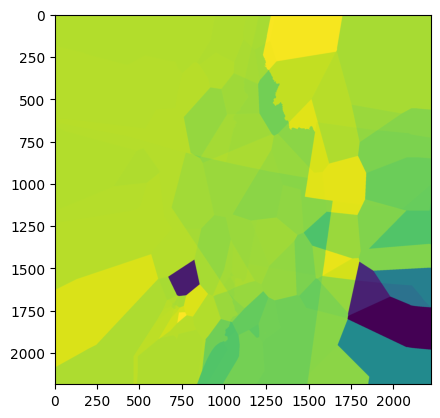

<Axes: >

In [126]:
show(nearest_values)

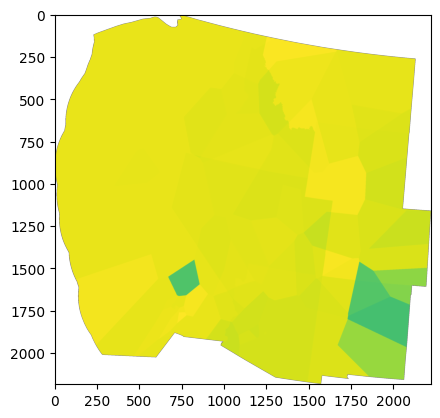

<Axes: >

In [113]:
show(lmp_array)

In [118]:
np.nanmin(lmp_array)

np.float64(0.0)

In [125]:
np.nanmin(nearest_values)

np.float64(48.62006081552335)

In [112]:
nearest_values

array([[ 0.        ,  0.        ,  0.        , ..., 66.41736492,
        66.41736492, 66.41736492],
       [ 0.        ,  0.        ,  0.        , ..., 66.41736492,
        66.41736492, 66.41736492],
       [ 0.        ,  0.        ,  0.        , ..., 66.41736492,
        66.41736492, 66.41736492],
       ...,
       [66.6170059 , 66.6170059 , 66.6170059 , ..., 58.43242058,
        58.43242058, 58.43242058],
       [66.6170059 , 66.6170059 , 66.6170059 , ..., 58.43242058,
        58.43242058, 58.43242058],
       [66.6170059 , 66.6170059 , 66.6170059 , ..., 58.43242058,
        58.43242058, 58.43242058]], shape=(2186, 2222))

In [124]:
g[g.value == 0]

,index,raster_val,row,col,region_name,transmission_cost,pipeline_cost,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,lmp,value


In [104]:
g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
g

,index,raster_val,row,col,region_name,transmission_cost,pipeline_cost,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,lmp
0,731,53,0,731,washington,68751152,165683984,"POLYGON ((-1994329.138 1569638.107, -1994329.1...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,66.741998
1,732,53,0,732,washington,67676304,163784720,"POLYGON ((-1993329.328 1569638.107, -1993329.3...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,NaN
2,2953,53,1,731,washington,67901048,164348528,"POLYGON ((-1994329.138 1568638.285, -1994329.1...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,66.741998
3,2954,53,1,732,washington,66812524,162433664,"POLYGON ((-1993329.328 1568638.285, -1993329.3...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,66.741998
4,2955,53,1,733,washington,65734948,160529840,"POLYGON ((-1992329.518 1568638.285, -1992329.5...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,66.741998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897121,4856637,35,2185,1567,new_mexico,144819840,195344800,"POLYGON ((-1158488.103 -614973.49, -1158488.10...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,NaN
3897122,4856638,35,2185,1568,new_mexico,146214944,195831648,"POLYGON ((-1157488.293 -614973.49, -1157488.29...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,NaN
3897123,4856639,35,2185,1569,new_mexico,147611248,196345008,"POLYGON ((-1156488.484 -614973.49, -1156488.48...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,NaN
3897124,4856640,35,2185,1570,new_mexico,149008736,196746432,"POLYGON ((-1155488.674 -614973.49, -1155488.67...",NaN,0.0,45,3,cooler,gridcerf_solar_pv_centralized_no-cooling,2045,NaN


In [64]:
gpd.read_file('/Volumes/im3/projects/cerf/exp_b_paper/data/all_coord.geojson')

,xcoord,ycoord,row,col,transmission_cost,pipeline_cost,region_id,geometry
0,-2.725690e+06,1.570138e+06,0,0,929025536,1604493184,0,"POLYGON ((-2725189.947 1570637.929, -2725189.9..."
1,-2.724690e+06,1.570138e+06,0,1,927699456,1602272128,0,"POLYGON ((-2724189.947 1570637.929, -2724189.9..."
2,-2.723690e+06,1.570138e+06,0,2,926373568,1600051328,0,"POLYGON ((-2723189.947 1570637.929, -2723189.9..."
3,-2.722690e+06,1.570138e+06,0,3,925047872,1597830784,0,"POLYGON ((-2722189.947 1570637.929, -2722189.9..."
4,-2.721690e+06,1.570138e+06,0,4,923722304,1595610624,0,"POLYGON ((-2721189.947 1570637.929, -2721189.9..."
...,...,...,...,...,...,...,...,...
4857287,-5.086899e+05,-6.148621e+05,2185,2217,72232984,6997956,48,"POLYGON ((-508189.947 -614362.071, -508189.947..."
4857288,-5.076899e+05,-6.148621e+05,2185,2218,73095968,4665304,48,"POLYGON ((-507189.947 -614362.071, -507189.947..."
4857289,-5.066899e+05,-6.148621e+05,2185,2219,73958952,2332652,48,"POLYGON ((-506189.947 -614362.071, -506189.947..."
4857290,-5.056899e+05,-6.148621e+05,2185,2220,74821944,0,48,"POLYGON ((-505189.947 -614362.071, -505189.947..."


In [18]:
len(gdf_feature_subset[gdf_feature_subset.region_name == 'california'])

772

In [ ]:
g['rcp'] = rcp
g['ssp'] = ssp
g['climate'] = climate
g['tech_name'] = tech
g['sited_year'] = timestep
g['sited'] = g['sited'].fillna(0)

In [14]:
g['region_id'] = region_at_points
g['region_name'] = g['region_id'].map(state_fips)

In [19]:
len(g[(g.sited == 1) & (g.region_name == 'california')])

771

In [74]:
%%time
import rasterio
import geopandas as gpd
from shapely.geometry import box

# 1. Open the raster file
raster_path = "/Volumes/im3/projects/cerf/exp_b_paper/data/west_state_raster.tif"
with rasterio.open(raster_path) as src:
    image = src.read(1)
    transform = src.transform
    crs = src.crs

    # Get raster dimensions
    height, width = image.shape

    # 2. Create a polygon for every pixel
    polygons = []
    values = []

    rows=[]
    cols=[]
    for row in range(height):
        for col in range(width):
            # Get the bounding box for this pixel
            x_min, y_max = transform * (col, row)
            x_max, y_min = transform * (col + 1, row + 1)

            # Create a polygon and store the raster value
            polygons.append(box(x_min, y_min, x_max, y_max))
            values.append(image[row, col])
            rows.append(row)
            cols.append(col)

    rs = np.array(rows).flatten()
    cs = np.array(cols).flatten()

    # 3. Create a GeoDataFrame
    gdf = gpd.GeoDataFrame({'raster_val': values, 'geometry': polygons, 'row':rs, 'col':cs}, crs=crs)

# Optional: drop NoData pixels if needed
if src.nodata is not None:
    gdf = gdf[gdf['raster_val'] != src.nodata]

CPU times: user 46.2 s, sys: 924 ms, total: 47.1 s
Wall time: 53.2 s


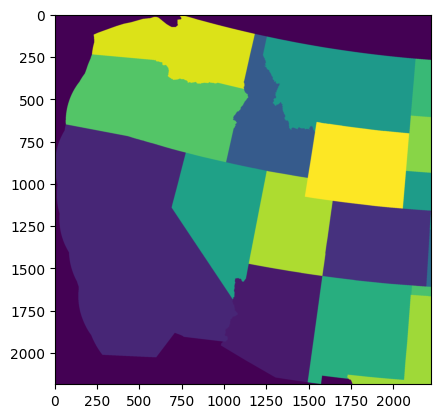

<Axes: >

In [76]:
show(image)

In [75]:
gdf

,raster_val,geometry,row,col
731,53,"POLYGON ((-1994329.138 1569638.107, -1994329.1...",0,731
732,53,"POLYGON ((-1993329.328 1569638.107, -1993329.3...",0,732
2953,53,"POLYGON ((-1994329.138 1568638.285, -1994329.1...",1,731
2954,53,"POLYGON ((-1993329.328 1568638.285, -1993329.3...",1,732
2955,53,"POLYGON ((-1992329.518 1568638.285, -1992329.5...",1,733
...,...,...,...,...
4857287,48,"POLYGON ((-508611.701 -614973.49, -508611.701 ...",2185,2217
4857288,48,"POLYGON ((-507611.891 -614973.49, -507611.891 ...",2185,2218
4857289,48,"POLYGON ((-506612.081 -614973.49, -506612.081 ...",2185,2219
4857290,48,"POLYGON ((-505612.271 -614973.49, -505612.271 ...",2185,2220


In [77]:
state_fips = {
    4: 'arizona',  
    6: 'california',  
    8: 'colorado', 
    16: 'idaho',
    30: 'montana',
    32: 'nevada', 
    35: 'new_mexico', 
    41: 'oregon', 
    49: 'utah', 
    53: 'washington',
    56: 'wyoming'
}
gdf['region_name'] = gdf['raster_val'].map(state_fips)
gdf = gdf[~gdf.region_name.isna()]


In [78]:
gdf = gdf.reset_index()
gdf

,index,raster_val,geometry,row,col,region_name
0,731,53,"POLYGON ((-1994329.138 1569638.107, -1994329.1...",0,731,washington
1,732,53,"POLYGON ((-1993329.328 1569638.107, -1993329.3...",0,732,washington
2,2953,53,"POLYGON ((-1994329.138 1568638.285, -1994329.1...",1,731,washington
3,2954,53,"POLYGON ((-1993329.328 1568638.285, -1993329.3...",1,732,washington
4,2955,53,"POLYGON ((-1992329.518 1568638.285, -1992329.5...",1,733,washington
...,...,...,...,...,...,...
3897121,4856637,35,"POLYGON ((-1158488.103 -614973.49, -1158488.10...",2185,1567,new_mexico
3897122,4856638,35,"POLYGON ((-1157488.293 -614973.49, -1157488.29...",2185,1568,new_mexico
3897123,4856639,35,"POLYGON ((-1156488.484 -614973.49, -1156488.48...",2185,1569,new_mexico
3897124,4856640,35,"POLYGON ((-1155488.674 -614973.49, -1155488.67...",2185,1570,new_mexico


In [79]:
# collect the coordinates of the centroid of each grid cell
coords = [(x,y) for x, y in zip(gdf['geometry'].centroid.x, gdf['geometry'].centroid.y)]
coords

[(-1994829.0424733174, 1570138.0181059581),
 (-1993829.232623669, 1570138.0181059581),
 (-1994829.0424733174, 1569138.1958647536),
 (-1993829.232623669, 1569138.1958647536),
 (-1992829.4227740206, 1569138.1958647536),
 (-1991829.6129243725, 1569138.1958647536),
 (-1990829.803074724, 1569138.1958647536),
 (-1993829.232623669, 1568138.3736235492),
 (-1992829.4227740206, 1568138.3736235492),
 (-1991829.6129243725, 1568138.3736235492),
 (-1990829.803074724, 1568138.3736235492),
 (-1989829.993225076, 1568138.3736235492),
 (-1988830.1833754275, 1568138.3736235492),
 (-1987830.3735257795, 1568138.3736235492),
 (-1992829.4227740206, 1567138.551382345),
 (-1991829.6129243725, 1567138.551382345),
 (-1990829.803074724, 1567138.551382345),
 (-1989829.993225076, 1567138.551382345),
 (-1988830.1833754275, 1567138.551382345),
 (-1987830.3735257795, 1567138.551382345),
 (-1986830.5636761314, 1567138.551382345),
 (-1985830.7538264832, 1567138.551382345),
 (-1984830.9439768349, 1567138.551382345),
 (-19

In [71]:
with rasterio.open(transmission_cost_raster_fn) as src:
    transmission_cost_at_points = [int(i[0]) for i in src.sample(coords)]  
# Gas pipeline cost
with rasterio.open(gas_pipeline_cost_raster_fn) as src:
    gas_pipeline_cost_at_points = [int(i[0]) for i in src.sample(coords)]

    gdf['transmission_cost'] = transmission_cost_at_points
gdf['pipeline_cost'] = gas_pipeline_cost_at_points

In [81]:
gdf[gdf.transmission_cost == 0]

,index,raster_val,geometry,row,col,region_name,transmission_cost,pipeline_cost
1030,51910,53,"POLYGON ((-1921343.019 1546642.195, -1921343.0...",23,804,washington,0,4665304
2337,69652,53,"POLYGON ((-1955336.553 1538643.618, -1955336.5...",31,770,washington,0,50084160
6038,98550,53,"POLYGON ((-1943338.835 1525645.928, -1943338.8...",44,782,washington,0,17764948
19113,160752,53,"POLYGON ((-1957336.173 1497650.906, -1957336.1...",72,768,washington,0,58316300
20444,165311,53,"POLYGON ((-1842358.04 1495651.261, -1842358.04...",74,883,washington,0,196414272
...,...,...,...,...,...,...,...,...
3841845,4636419,4,"POLYGON ((-1398442.467 -515991.088, -1398442.4...",2086,1327,arizona,0,36882464
3866717,4701240,35,"POLYGON ((-1015515.295 -544985.933, -1015515.2...",2115,1710,new_mexico,0,0
3877676,4732030,4,"POLYGON ((-1333454.827 -558983.445, -1333454.8...",2129,1392,arizona,0,34441192
3889326,4769729,4,"POLYGON ((-1408440.566 -575980.423, -1408440.5...",2146,1317,arizona,0,0


In [60]:
np.min(transmission_cost_at_points)

np.int64(0)

In [83]:
gdf.sort_values(by='transmission_cost')

,index,raster_val,geometry,row,col,region_name,transmission_cost,pipeline_cost
3330515,3910200,35,"POLYGON ((-1023513.774 -189049.215, -1023513.7...",1759,1702,new_mexico,0,60828120
1657257,2126085,56,"POLYGON ((-872542.486 613808.044, -872542.486 ...",956,1853,wyoming,0,65063848
2267249,2772835,8,"POLYGON ((-724570.628 322859.772, -724570.628 ...",1247,2001,colorado,0,32657128
360619,709727,53,"POLYGON ((-1816362.984 1250694.812, -1816362.9...",319,909,washington,0,81609488
907189,1317249,30,"POLYGON ((-900537.162 977743.34, -900537.162 9...",592,1825,montana,0,9330608
...,...,...,...,...,...,...,...,...
3767831,4468721,6,"POLYGON ((-2446243.19 -441004.42, -2446243.19 ...",2011,279,california,649723584,1072071168
3769170,4470944,6,"POLYGON ((-2445243.38 -442004.242, -2445243.38...",2012,280,california,650060544,1072756160
3770505,4473167,6,"POLYGON ((-2444243.57 -443004.065, -2444243.57...",2013,281,california,650403264,1073450816
3769169,4470943,6,"POLYGON ((-2446243.19 -442004.242, -2446243.19...",2012,279,california,650852544,1074025984


In [82]:
gdf.to_file('/Volumes/im3/projects/cerf/exp_b_paper/data/state_all_coord_w_interconnection.geojson')

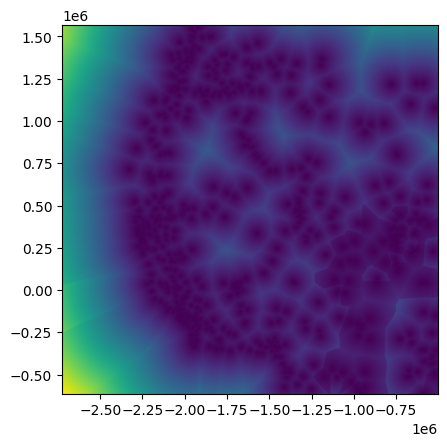

In [52]:
from rasterio.plot import show
with rasterio.open(transmission_cost_raster_fn) as src:
    show(src)

In [31]:
a = gpd.sjoin(gdf, gdf_feature_subset[['sited', 'geometry']], how='left')

In [34]:
len(a[(a.sited == 1) & (a.region_name == 'california')])

772

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely
from shapely import Point 
import sys
import os 
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from joblib import Parallel, delayed
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
import logging

In [5]:
# Define directories for data and outputs
run_dir = '/Volumes/im3/projects/cerf/exp_b_paper'
exp_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/experiment_runs/run_110824'
exp_data_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/models/cerf/data'
gridcerf_dir = '/Volumes/im3/exp_b/exp_b_multi_model_coupling_west/external_data/gridcerf_2.1'

data_dir = os.path.join(run_dir, 'data')
output_dir = os.path.join(run_dir, 'output')
west_lmp_raster_fn = os.path.join(data_dir, 'west_lmp_polygons.tif')
west_state_raster_fn = os.path.join(data_dir, 'west_state_raster.tif')
transmission_cost_raster_fn = os.path.join(data_dir, 'transmission_cost_raster_west.tif')
gas_pipeline_cost_raster_fn = os.path.join(data_dir, 'gas_pipeline_cost_raster_west.tif')
power_plant_file = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')

In [48]:


# -------------------- PATHS AND CONSTANTS --------------------



# List of scenario names
scenario_list = [
    'rcp45cooler_ssp3',
    'rcp45cooler_ssp5',
    'rcp85cooler_ssp3',
    'rcp85cooler_ssp5',
    'rcp45hotter_ssp3',
    'rcp45hotter_ssp5',
    'rcp85hotter_ssp3',
    'rcp85hotter_ssp5'
]

# Mapping of state FIPS codes to state names
state_fips = {
    4: 'arizona',  
    6: 'california',  
    8: 'colorado', 
    16: 'idaho',
    30: 'montana',
    32: 'nevada', 
    35: 'new_mexico', 
    41: 'oregon', 
    49: 'utah', 
    53: 'washington',
    56: 'wyoming'
}

# Mapping of technology names to analysis paths
analysis_path_dict = {
    'gridcerf_gas_cc_no-ccs_dry': 'gas/gridcerf_gas_cc_no-ccs_dry',                                  
    'gridcerf_gas_cc_no-ccs_recirculating': 'gas/gridcerf_gas_cc_no-ccs_recirculating',    
    'gridcerf_gas_turbine_no-ccs_no-cooling': 'gas/gridcerf_gas_turbine_no-ccs_no-cooling',    
    'gridcerf_solar_pv_centralized_no-cooling': 'solar/gridcerf_solar_pv_centralized_no-cooling_6cf',    
    'gridcerf_wind_onshore_hubheight100_no-cooling': 'wind/gridcerf_wind_onshore_hubheight100_no-cooling_5cf', 
    'gridcerf_wind_onshore_hubheight120_no-cooling': 'wind/gridcerf_wind_onshore_hubheight120_no-cooling_5cf',
    'gridcerf_wind_onshore_hubheight140_no-cooling': 'wind/gridcerf_wind_onshore_hubheight140_no-cooling_5cf',
    'gridcerf_wind_onshore_hubheight80_no-cooling': 'wind/gridcerf_wind_onshore_hubheight100_no-cooling_5cf',
}

# Inverted mapping for state names to FIPS codes
inverted_state_fips = {value: key for key, value in state_fips.items()}

# -------------------- DATA PREPARATION FUNCTIONS --------------------

def get_feature_gdf(power_plant_file):
    """
    Load and process the power plant GeoDataFrame, extracting relevant features and scenario info.
    """
    gdf = gpd.read_file(power_plant_file)

    logging.info("Processing geodataframe...")
    gdf_feature = gdf[gdf.cerf_sited == True][[
        'scenario', 'region_name', 'tech_name', 'tech_simple', 'xcoord', 'ycoord',
        'generation_type', 'sited_year', 'interconnection_cost_usd_per_year', 
        'capacity_factor_fraction', 'geometry'
    ]].copy()
    # Extract sub-type, ccs, and cooling type from tech_name
    gdf_feature['sub_type'] = gdf_feature['tech_name'].str.split("_", expand=True)[2]
    gdf_feature['ccs'] = gdf_feature['tech_name'].str.split("_", expand=True)[3]
    gdf_feature['cooling_type'] = gdf_feature['tech_name'].str.split("_", expand=True)[4]
    # Adjust for wind generation
    gdf_feature['sub_type'] = np.where(gdf_feature.generation_type == 'Wind', gdf_feature['ccs'], gdf_feature['sub_type'])
    gdf_feature['ccs'] = np.where(gdf_feature.generation_type == 'Wind', 'no-ccs', gdf_feature['ccs'])
    # Extract scenario parameters
    gdf_feature['rcp'] = np.where(gdf_feature.scenario.str.contains('rcp45'), 45, 85)
    gdf_feature['ssp'] = np.where(gdf_feature.scenario.str.contains('ssp3'), 3, 5)
    gdf_feature['climate'] = np.where(gdf_feature.scenario.str.contains('cooler'), 'cooler', 'hotter')

    return gdf_feature

def get_cf_df(gdf_feature):
    """
    Calculate average capacity factor by technology and region.
    """
    cfdf = gdf_feature.copy()
    cfdf['tech_simple'] = np.where(cfdf['tech_simple'] == 'Gas CC (CCS)', 'Gas CC', cfdf['tech_simple'])
    gen_list = ['Gas CC', 'Gas CT', 'Solar PV', 'Wind (Onshore)']
    cfdf = cfdf[cfdf['tech_simple'].isin(gen_list)]
    cfdf = cfdf[['scenario', 'region_name', 'tech_simple', 'sited_year', 'capacity_factor_fraction']].groupby(
        ['region_name', 'sited_year', 'scenario', 'tech_simple'], as_index=False).mean()
    return cfdf

def get_cf_bin(capacity_factor_fraction):
    """
    Get the correct start and through index values to average over for calculating LMP.
    """
    if capacity_factor_fraction == 1.0:
        start_index = 0
        through_index = 8760
    elif capacity_factor_fraction >= 0.5:
        start_index = int(np.ceil(8760 * (1 - capacity_factor_fraction)))
        through_index = 8760
    elif capacity_factor_fraction == 0.0:
        msg = f"The capacity factor provided `{capacity_factor_fraction}` is outside the bounds of 0.0 through 1.0"
        raise ValueError(msg)
    else:
        start_index = 0
        through_index = int(np.ceil(8760 * capacity_factor_fraction))
    return start_index, through_index

def pivot_lmp_file(input_lmp_df):
    """
    Pivot the LMP DataFrame to wide format (hours x buses).
    """
    buses_str = [*input_lmp_df['Bus'].unique()]
    buses_int = [int(i[4:]) for i in buses_str]
    number_of_nodes = len(buses_int)
    hour_nums = [*range(1,8761)]
    number_of_hours = len(hour_nums)
    Organized_LMP = pd.DataFrame(np.zeros((number_of_hours,number_of_nodes)),columns=buses_str)
    for bus in buses_str:
        Bus_LMPs = input_lmp_df.loc[input_lmp_df['Bus']==bus]['Value'].values
        Organized_LMP.loc[:,bus] = Bus_LMPs
    Organized_LMP.columns = buses_int
    Organized_LMP.insert(loc=0, column='hour', value=hour_nums)
    return Organized_LMP

def get_lmp_dict(wide_lmp_df, capacity_factor_fraction, operational_hours_file=None):
    """
    Create a dictionary of LMP values for each power zone based on tech capacity factor or operational hours.
    """
    if operational_hours_file is None:
        # Use capacity factor bin method
        start_index, through_index = get_cf_bin(capacity_factor_fraction)
        # Sort by descending LMP for each zone
        for j in wide_lmp_df.columns:
            wide_lmp_df[j] = wide_lmp_df[j].sort_values(ascending=False).values
        # Average over the relevant hours
        lmp_dict = wide_lmp_df.iloc[start_index:through_index].mean(axis=0).to_dict()
    else:
        # Use operational hours file
        operational_hours_df = pd.read_csv(operational_hours_file)
        operational_hours_index_list = operational_hours_df[operational_hours_df.operational == 1].index.to_list()
        lmp_dict = wide_lmp_df.iloc[operational_hours_index_list].mean(axis=0).to_dict()
    return lmp_dict

def get_tech_lmp_array(scenario, timestep, subset_df, tech_simple, west_lmp_raster_fn, west_state_raster_fn):
    """
    For a given scenario and timestep, create an array of LMP values for each grid cell, 
    mapped by region and technology.
    """
    with rasterio.open(west_lmp_raster_fn) as src:
        lmp_array = src.read(1)
    with rasterio.open(west_state_raster_fn) as src:
        state_array = src.read(1)
    go_dir = os.path.join(exp_dir, scenario, f'go/output/native_output/{timestep}/duals')
    for i in os.listdir(go_dir):
        if i.startswith(f'duals_{timestep-5}PI'):
            # Read in LMP DataFrame
            fn = os.path.join(go_dir, i)
            long_lmp_df = pd.read_parquet(fn, engine="fastparquet")
            lmp_df = pivot_lmp_file(input_lmp_df=long_lmp_df)
            lmp_df = lmp_df.drop('hour', axis=1)
            # Initialize array for this technology
            tech_array = np.zeros_like(lmp_array)

            # change to -99
            #tech_array[:] = np.nan            
            
            for region in subset_df.region_name.unique():
                # Get regional capacity factor
                cf_region = subset_df[subset_df.region_name == region]['capacity_factor_fraction'].iloc[0]
                # Use operational hours file for renewables
                if tech_simple in ['Solar PV', 'Wind (Onshore)']:
                    tech_short = 'solar' if tech_simple == 'Solar PV' else 'wind'
                    operational_hours_file = os.path.join(
                        exp_data_dir, 'cerf_setup_files', 'renewable_capacity_factor_files',
                        f'{region}_{tech_short}_operational_hours.csv'
                    )
                else:
                    operational_hours_file = None
                # Get LMP dictionary for region/tech
                lmp_dict = get_lmp_dict(
                    wide_lmp_df=lmp_df, 
                    capacity_factor_fraction=cf_region, 
                    operational_hours_file=operational_hours_file
                )
                lmp_dict[0] = np.nan  # Set nodata value
                dict_map_func = np.vectorize(lmp_dict.get)
                tech_lmp_arr = dict_map_func(lmp_array)
                region_id = inverted_state_fips[region]
                region_mask = state_array == region_id
                #region_mask = np.where(region_mask==0, np.nan, 1)
                tech_lmp_arr = tech_lmp_arr * region_mask
                # Add to composite tech array
                tech_array += tech_lmp_arr

        else:
            pass
    return tech_array

def create_full_grid_cell_array(west_lmp_raster_fn):
    """
    Create a GeoDataFrame of all grid cells in the study area, with coordinates and geometry.
    """
    logging.info("Creating geodataframe of all grid cells...")
    with rasterio.open(west_lmp_raster_fn) as src:
        transform = src.transform
        width = src.width
        height = src.height
        # Get all row/col indices
        rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
        xs, ys = rasterio.transform.xy(transform, rows, cols)
        xs = np.array(xs).flatten()
        ys = np.array(ys).flatten()
        rs = np.array(rows).flatten()
        cs = np.array(cols).flatten()
        all_coords = pd.DataFrame({'xcoord': xs, 'ycoord': ys, 'row':rs, 'col':cs})
        all_coords['geometry'] = [Point(x, y) for x, y in zip(xs, ys)]
        all_coord_gdf = gpd.GeoDataFrame(all_coords, geometry='geometry', crs='ESRI:102003')
        all_coord_gdf.geometry = all_coord_gdf.geometry.buffer(500, cap_style='square')
    # Return coordinates and GeoDataFrame
    coords = [(x,y) for x, y in zip(all_coord_gdf['xcoord'], all_coord_gdf['ycoord'])]
    return coords, all_coord_gdf

def collect_single_run_data(transmission_cost_raster_fn,
                            gas_pipeline_cost_raster_fn,
                            west_state_raster_fn,
                            coords=None):
    """
    Collect interconnection cost and region information for each grid cell in the study area.
    """
    logging.info("Collecting interconnection cost information...")
    # Transmission cost
    with rasterio.open(transmission_cost_raster_fn) as src:
        transmission_cost_at_points = [int(i[0]) for i in src.sample(coords)]      
    # Gas pipeline cost
    with rasterio.open(gas_pipeline_cost_raster_fn) as src:
        gas_pipeline_cost_at_points = [int(i[0]) for i in src.sample(coords)]      
    logging.info("Collecting state information...")
    # Region ID (state)
    with rasterio.open(west_state_raster_fn) as src:
        region_at_points = [int(i[0]) for i in src.sample(coords)]  
    return transmission_cost_at_points, gas_pipeline_cost_at_points, region_at_points

def collect_analysis_data(rcp,
                          ssp,
                          climate,
                          tech, 
                          gdf_feature,
                          all_coord_gdf, 
                          coords,
                          transmission_cost_at_points,
                          gas_pipeline_cost_at_points,
                          region_at_points,
                          state_fips=state_fips,
                          analysis_path_dict=analysis_path_dict, 
                          gridcerf_dir=gridcerf_dir):
    """
    For each scenario combination, build a dataframe of all grid cells in the study area and identify:
    - Whether it saw a siting of the given technology
    - Suitability of the grid cell
    - Locational marginal price (LMP) for the grid cell and timestep
    - Interconnection cost for the grid cell

    Filters out unsuitable grid cells and those in states with no development.
    Returns a dataframe of all sitings and non-sitings for all scenarios for the given timestep and technology.
    """
    # Map full technology name to tech_simple
    tech_simple_dict = gdf_feature.drop_duplicates(subset='tech_name')[['tech_name', 'tech_simple']].set_index('tech_name').to_dict()['tech_simple']
    gdf_list = []
    for timestep in range(2020, 2056, 5):       
        logging.info(f"Collecting data for timestep {timestep} and technology {tech}")     
        tech_simple = tech_simple_dict[tech]
        tech_path = analysis_path_dict[tech]
        suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')
        # Filter sited plants for this scenario/timestep/tech
        gdf_feature_subset = gdf_feature[
            (gdf_feature.rcp == rcp) & 
            (gdf_feature.ssp == ssp) & 
            (gdf_feature.climate == climate) & 
            (gdf_feature.tech_name == tech) &
            (gdf_feature.sited_year == timestep)
        ].copy()
        gdf_feature_subset['sited'] = 1
        # Spatial join: all grid cells with sited data
        g = gpd.sjoin(all_coord_gdf, gdf_feature_subset[['sited', 'geometry']], how='left')
        # Fill in missing parameters for non-sited cells
        g['rcp'] = rcp
        g['ssp'] = ssp
        g['climate'] = climate
        g['tech_name'] = tech
        g['sited_year'] = timestep
        g['sited'] = g['sited'].fillna(0)
        g['region_id'] = region_at_points
        g['region_name'] = g['region_id'].map(state_fips)
        # Collect suitability
        with rasterio.open(suit_fn) as src:
            suitability_at_points = [int(i[0]) for i in src.sample(coords)]       
        g['suitability'] = suitability_at_points
        # Collect interconnection cost
        g['transmission_cost'] =  transmission_cost_at_points
        g['pipeline_cost'] =  gas_pipeline_cost_at_points
        if 'gas' in tech:
            g['interconnection_cost'] = g['transmission_cost'] + g['pipeline_cost']
        else:
            g['interconnection_cost'] = g['transmission_cost']
        # Collect LMP information by row, col in dataframe
        lmp_array = get_tech_lmp_array(
            scenario=scenario, 
            timestep=timestep, 
            subset_df=gdf_feature_subset, 
            tech_simple=tech_simple, 
            west_lmp_raster_fn=west_lmp_raster_fn, 
            west_state_raster_fn=west_state_raster_fn
        )
        g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
        # Drop unsuitable or missing LMP rows
        g = g[g.suitability == 0]

        ## OPTION 2: set initialized lmp array to -99 and drop those values
        #g = g[g.lmp != -99] #drop the states that didn't see sitings
        g = g[~g.lmp.isna()]

        # ONLY CHANGE
        g = g[g.region_name.isin(gdf_feature_subset.region_name.unique())] # only keep states with sitings

        
        gdf_list.append(g)
    # Concatenate all dataframes for all timesteps
    gdf_list = [g.reset_index(drop=True) for g in gdf_list]
    timestep_df = pd.concat(gdf_list)
    # Categorical encoding for scenario variables
    timestep_df['rcp'] = np.where(timestep_df['rcp'] == 45, 0, 1)
    timestep_df['ssp'] = np.where(timestep_df['ssp'] == 3, 0, 1)
    timestep_df['climate'] = np.where(timestep_df['climate'] == 'cooler', 0, 1)
    return timestep_df

def create_balanced_dataset(df, resample_ratio=2):
    """
    Create a balanced dataset by resampling the data to have equal numbers of sitings and non-sitings.
    """
    sitings = df[df['sited'] == 1]
    non_sitings = df[df['sited'] == 0]
    # Resample non-sitings to match the number of sitings
    non_sitings_resampled = resample(non_sitings, n_samples=len(sitings)*resample_ratio, random_state=42)
    # Concatenate sitings and resampled non-sitings
    balanced_df = pd.concat([sitings, non_sitings_resampled])
    return balanced_df.reset_index(drop=True)

def balance_and_save(df, output_path, resample_ratio=2):
    """Balance the dataset and save it to a parquet file."""
    logging.info("Balancing dataset...")
    balanced_df = create_balanced_dataset(df, resample_ratio)
    balanced_df.to_csv(output_path, index=False)
    logging.info(f"Balanced dataset saved to {output_path}")
    return None



    # # Quick basic logging setup
    # logging.basicConfig(
    #     level=logging.INFO,  # Set to DEBUG for more details
    #     format='%(asctime)s - %(levelname)s - %(message)s'
    # )

    # logging.info("Starting data analysis script...")

    

In [ ]:
tech_number = 1
rcp = 45
ssp=3
climate ='cooler'
timestep = 2030

tech_list =[
#'gridcerf_gas_cc_no-ccs_dry',
# 'gridcerf_gas_cc_no-ccs_recirculating',
# 'gridcerf_gas_turbine_no-ccs_no-cooling',
# 'gridcerf_solar_pv_centralized_no-cooling',
'gridcerf_wind_onshore_hubheight100_no-cooling',
# 'gridcerf_wind_onshore_hubheight120_no-cooling',
# 'gridcerf_wind_onshore_hubheight140_no-cooling',
# 'gridcerf_wind_onshore_hubheight80_no-cooling'
]
tech = tech_list[tech_number - 1]

gdf_feature = get_feature_gdf(power_plant_file=power_plant_file)
tech_simple_dict = gdf_feature.drop_duplicates(subset='tech_name')[['tech_name', 'tech_simple']].set_index('tech_name').to_dict()['tech_simple']

west_lmp_raster_fn = os.path.join(data_dir, 'west_lmp_polygons.tif')
west_state_raster_fn = os.path.join(data_dir, 'west_state_raster.tif')
transmission_cost_raster_fn = os.path.join(data_dir, 'transmission_cost_raster_west.tif')
gas_pipeline_cost_raster_fn = os.path.join(data_dir, 'gas_pipeline_cost_raster_west.tif')
power_plant_file = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')


tech_simple = tech_simple_dict[tech]


cfdf = get_cf_df(gdf_feature=gdf_feature)

gdf_feature_subset = gdf_feature[ (gdf_feature.rcp == rcp) &  (gdf_feature.ssp == ssp) &   (gdf_feature.climate == climate) &   (gdf_feature.tech_name == tech) & (gdf_feature.sited_year == timestep)
        ].copy()
gdf_feature_subset['sited'] = 1

all_coord_gdf = gpd.read_file(os.path.join(data_dir, 'all_coord_gdf.geojson'))


coords = [(x,y) for x, y in zip(all_coord_gdf['xcoord'], all_coord_gdf['ycoord'])]
# transmission_cost_at_points = all_coord_gdf['transmission_cost'].tolist()
# gas_pipeline_cost_at_points = all_coord_gdf['pipeline_cost'].tolist()
region_at_points = all_coord_gdf['region_id'].tolist()

print('Collecting data for technology:', tech)


In [49]:
%%time
scenario = 'rcp45cooler_ssp3'
lmp_array = get_tech_lmp_array(
            scenario=scenario, 
            timestep=timestep, 
            subset_df=gdf_feature_subset, 
            tech_simple=tech_simple, 
            west_lmp_raster_fn=west_lmp_raster_fn, 
            west_state_raster_fn=west_state_raster_fn

)

CPU times: user 5.25 s, sys: 362 ms, total: 5.61 s
Wall time: 33.5 s


In [43]:
lmp_array

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(2186, 2222))

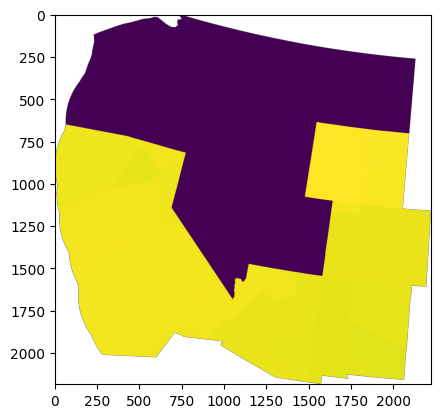

<Axes: >

In [50]:
show(lmp_array)

In [51]:
tech_path = analysis_path_dict[tech]
suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')
gdf_list = []

# Spatial join: all grid cells with sited data
g = gpd.sjoin(all_coord_gdf, gdf_feature_subset[['sited', 'geometry']], how='left')
# Fill in missing parameters for non-sited cells
g['rcp'] = rcp
g['ssp'] = ssp
g['climate'] = climate
g['tech_name'] = tech
g['sited_year'] = timestep
g['sited'] = g['sited'].fillna(0)
g['region_id'] = region_at_points
g['region_name'] = g['region_id'].map(state_fips)
# Collect suitability
with rasterio.open(suit_fn) as src:
    suitability_at_points = [int(i[0]) for i in src.sample(coords)]       
g['suitability'] = suitability_at_points
# Collect interconnection cost
# g['transmission_cost'] =  transmission_cost_at_points
# g['pipeline_cost'] =  gas_pipeline_cost_at_points
# if 'gas' in tech:
#     g['interconnection_cost'] = g['transmission_cost'] + g['pipeline_cost']
# else:
#     g['interconnection_cost'] = g['transmission_cost']
# Collect LMP information by row, col in dataframe



In [60]:
power_plant_file = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')
gdf_feature = get_feature_gdf(power_plant_file=power_plant_file)

In [90]:
pd.read_csv('/Volumes/im3/projects/cerf/exp_b_paper/output_100825/feature_analysis_balanced_gridcerf_gas_cc_no-ccs_recirculating_rcp45cooler_ssp3.csv')

,xcoord,ycoord,row,col,transmission_cost,pipeline_cost,region_id,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,region_name,suitability,interconnection_cost,lmp
0,-1.668690e+06,1.221138e+06,349,1057,21492866,16494340,53,POLYGON ((-1668189.9474910195 1221637.92922656...,1798.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2020,washington,0,37987206,54.391977
1,-1.621690e+06,1.200138e+06,370,1104,18839082,14752986,53,POLYGON ((-1621189.9474910195 1200637.92922656...,1796.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2020,washington,0,33592068,54.391977
2,-1.614690e+06,1.197138e+06,373,1111,29728612,2332652,53,POLYGON ((-1614189.9474910195 1197637.92922656...,1797.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2020,washington,0,32061264,54.391977
3,-1.615690e+06,1.189138e+06,381,1110,25818288,12561715,53,POLYGON ((-1615189.9474910195 1189637.92922656...,1799.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2020,washington,0,38380003,83.133682
4,-1.613690e+06,1.183138e+06,387,1112,17959046,13601581,53,POLYGON ((-1613189.9474910195 1183637.92922656...,1795.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2020,washington,0,31560627,83.133682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-6.636899e+05,-2.058621e+05,1776,2062,74950608,133614336,35,POLYGON ((-663189.9474910195 -205362.070773439...,NaN,0.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2050,new_mexico,0,208564944,39.370793
299,-1.050690e+06,-1.786207e+04,1588,1675,2869228,0,35,POLYGON ((-1050189.9474910195 -17362.070773439...,NaN,0.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2050,new_mexico,0,2869228,43.956780
300,-1.055690e+06,-2.486207e+04,1595,1670,5142653,0,35,POLYGON ((-1055189.9474910195 -24362.070773439...,16245.0,1.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2055,new_mexico,0,5142653,39.187921
301,-6.626899e+05,-2.058621e+05,1776,2063,75061016,131995952,35,POLYGON ((-662189.9474910195 -205362.070773439...,NaN,0.0,0,0,0,gridcerf_gas_cc_no-ccs_recirculating,2055,new_mexico,0,207056968,27.149877


In [127]:
from tqdm import tqdm
g = gdf_feature.copy()
tech_list =[
    'gridcerf_gas_cc_no-ccs_recirculating',
    'gridcerf_gas_turbine_no-ccs_no-cooling',
    'gridcerf_solar_pv_centralized_no-cooling',
    'gridcerf_wind_onshore_hubheight100_no-cooling',
    'gridcerf_wind_onshore_hubheight120_no-cooling',
    'gridcerf_wind_onshore_hubheight140_no-cooling',
    'gridcerf_wind_onshore_hubheight80_no-cooling'
    ]
g = g[g.tech_name.isin(tech_list)]
for scenario in tqdm(g.scenario.unique()):
    g_s = g[g.scenario == scenario]
    for tech in g_s.tech_name.unique():
        g_t = g_s[g_s.tech_name == tech]

        fn = f'/Volumes/im3/projects/cerf/exp_b_paper/output_100625_2/feature_analysis_balanced_{tech}_{scenario}.csv'
        if os.path.exists(fn):
            bdf = pd.read_csv(fn)
            bdf = bdf[bdf.sited == 1]

            
            for time in g_t.sited_year.unique():
                bdf_time = bdf[bdf.sited_year == time]
                g_time = g_t[g_t.sited_year == time]
                for state in g_time.region_name.unique():
                    g_state = g_time[g_time.region_name == state]
                    bdf_state = bdf_time[bdf_time.region_name == state]
                    g_state = g_state.count().iloc[0]
                    bdf_state = bdf_state.count().iloc[0]

                    if g_state == bdf_state:
                        pass
                        #print("GOOD", scenario, tech, time, state, f"sited: {g_state}",  f"balanced: {bdf_state}") 
                    else:
                        print(scenario, tech, time, state, f"sited: {g_state}",  f"balanced: {bdf_state}") 
        else:
            pass
            #print(fn)

        

100%|█████████████████████████████████████████████| 8/8 [00:47<00:00,  5.97s/it]


In [130]:
bdf_time

,index,raster_val,row,col,region_name,transmission_cost,pipeline_cost,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,suitability,interconnection_cost,lmp
144,554141,53,249,863,washington,4975661,46184152,POLYGON ((-1862354.2373949229 1320682.36892548...,191484.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4975661,46.878998
145,554142,53,249,864,washington,4363943,44565252,POLYGON ((-1861354.4275452746 1320682.36892548...,191472.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4363943,46.878998
146,554144,53,249,866,washington,4363943,41268824,POLYGON ((-1859354.807845978 1320682.368925485...,191468.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4363943,46.878998
147,554145,53,249,867,washington,4975661,39586416,POLYGON ((-1858354.9979963298 1320682.36892548...,191485.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4975661,46.878998
148,556362,53,250,862,washington,4975661,46184152,POLYGON ((-1863354.0472445711 1319682.54668428...,191512.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4975661,46.878998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7437,4632684,35,2084,2036,new_mexico,4975661,0,POLYGON ((-689577.2837575141 -513991.443684403...,191169.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4975661,40.775446
7438,4634907,35,2085,2037,new_mexico,4975661,2332652,POLYGON ((-688577.473907866 -514991.2659256079...,191173.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,4975661,40.775446
7439,4747987,35,2136,1795,new_mexico,10391896,32406236,POLYGON ((-930531.4575227448 -565982.200227027...,191195.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,10391896,44.348714
7440,4750209,35,2137,1795,new_mexico,9763730,30414060,POLYGON ((-930531.4575227448 -566982.022468231...,191159.0,1.0,1,1,0,gridcerf_wind_onshore_hubheight140_no-cooling,2055,0,9763730,44.348714


In [90]:
from tqdm import tqdm
g = gdf_feature.copy()
tech_list =[
    'gridcerf_gas_cc_no-ccs_recirculating',
    'gridcerf_gas_turbine_no-ccs_no-cooling',
    'gridcerf_solar_pv_centralized_no-cooling',
    'gridcerf_wind_onshore_hubheight100_no-cooling',
    'gridcerf_wind_onshore_hubheight120_no-cooling',
    'gridcerf_wind_onshore_hubheight140_no-cooling',
    'gridcerf_wind_onshore_hubheight80_no-cooling'
    ]
g = g[g.tech_name.isin(tech_list)]
for scenario in tqdm(g.scenario.unique()):
    g_s = g[g.scenario == scenario]
    for tech in g_s.tech_name.unique():
        g_t = g_s[g_s.tech_name == tech]

        fn = f'/Volumes/im3/projects/cerf/exp_b_paper/output_100625/feature_analysis_balanced_{tech}_{scenario}.csv'
        if os.path.exists(fn):
            bdf = pd.read_csv(fn)
            bdf = bdf[bdf.sited == 1]

            
            for time in g_t.sited_year.unique():
                bdf_time = bdf[bdf.sited_year == time]
                g_time = g_t[g_t.sited_year == time]

                b_count = bdf_time.count().iloc[0]
                g_count = g_time.count().iloc[0]
                
                # for state in g_time.region_name.unique():
                #     g_state = g_time[g_time.region_name == state]
                #     bdf_state = bdf_time[bdf_time.region_name == state]
                #     g_state = g_state.count().iloc[0]
                #     bdf_state = bdf_state.count().iloc[0]

                if g_count == b_count:
                    pass
                    #print("GOOD", scenario, tech, time, state, f"sited: {g_state}",  f"balanced: {bdf_state}") 
                else:
                    print(scenario, tech, time, f"sited: {g_count}",  f"balanced: {b_count}") 
        else:
            pass
            #print(fn)

        

  0%|                                                     | 0/8 [00:00<?, ?it/s]

rcp45cooler_ssp3 gridcerf_gas_turbine_no-ccs_no-cooling 2025 sited: 45 balanced: 44
rcp45cooler_ssp3 gridcerf_solar_pv_centralized_no-cooling 2045 sited: 1026 balanced: 1020
rcp45cooler_ssp3 gridcerf_solar_pv_centralized_no-cooling 2055 sited: 529 balanced: 528
rcp45cooler_ssp3 gridcerf_wind_onshore_hubheight80_no-cooling 2020 sited: 1950 balanced: 1946
rcp45cooler_ssp3 gridcerf_wind_onshore_hubheight120_no-cooling 2035 sited: 1092 balanced: 1089


 12%|█████▋                                       | 1/8 [00:09<01:06,  9.50s/it]

rcp45cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2045 sited: 2144 balanced: 2137
rcp45cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2050 sited: 2782 balanced: 2781
rcp45cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2055 sited: 2427 balanced: 2420
rcp45cooler_ssp5 gridcerf_gas_turbine_no-ccs_no-cooling 2025 sited: 51 balanced: 50
rcp45cooler_ssp5 gridcerf_solar_pv_centralized_no-cooling 2040 sited: 1448 balanced: 1447
rcp45cooler_ssp5 gridcerf_solar_pv_centralized_no-cooling 2045 sited: 1434 balanced: 1433
rcp45cooler_ssp5 gridcerf_solar_pv_centralized_no-cooling 2055 sited: 959 balanced: 952
rcp45cooler_ssp5 gridcerf_wind_onshore_hubheight80_no-cooling 2020 sited: 1899 balanced: 1895
rcp45cooler_ssp5 gridcerf_wind_onshore_hubheight100_no-cooling 2030 sited: 1398 balanced: 1395
rcp45cooler_ssp5 gridcerf_wind_onshore_hubheight120_no-cooling 2040 sited: 2267 balanced: 2261


 25%|███████████▎                                 | 2/8 [00:23<01:11, 11.96s/it]

rcp45cooler_ssp5 gridcerf_wind_onshore_hubheight140_no-cooling 2045 sited: 2877 balanced: 2873
rcp45cooler_ssp5 gridcerf_wind_onshore_hubheight140_no-cooling 2055 sited: 3367 balanced: 3358
rcp85cooler_ssp3 gridcerf_gas_turbine_no-ccs_no-cooling 2025 sited: 57 balanced: 55
rcp85cooler_ssp3 gridcerf_gas_turbine_no-ccs_no-cooling 2035 sited: 34 balanced: 33
rcp85cooler_ssp3 gridcerf_solar_pv_centralized_no-cooling 2045 sited: 979 balanced: 973
rcp85cooler_ssp3 gridcerf_wind_onshore_hubheight80_no-cooling 2020 sited: 1606 balanced: 1602


 62%|████████████████████████████▏                | 5/8 [00:26<00:12,  4.21s/it]

rcp85cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2045 sited: 1202 balanced: 1200
rcp85cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2050 sited: 1918 balanced: 1915
rcp85cooler_ssp3 gridcerf_wind_onshore_hubheight140_no-cooling 2055 sited: 1469 balanced: 1465
rcp85cooler_ssp5 gridcerf_gas_turbine_no-ccs_no-cooling 2025 sited: 71 balanced: 69
rcp85cooler_ssp5 gridcerf_gas_turbine_no-ccs_no-cooling 2040 sited: 33 balanced: 32
rcp85cooler_ssp5 gridcerf_wind_onshore_hubheight80_no-cooling 2020 sited: 1546 balanced: 1545
rcp85cooler_ssp5 gridcerf_wind_onshore_hubheight100_no-cooling 2025 sited: 171 balanced: 169


100%|█████████████████████████████████████████████| 8/8 [00:30<00:00,  3.78s/it]

rcp85cooler_ssp5 gridcerf_wind_onshore_hubheight140_no-cooling 2045 sited: 726 balanced: 723
rcp85cooler_ssp5 gridcerf_wind_onshore_hubheight140_no-cooling 2055 sited: 811 balanced: 808


In [89]:
g_state = g_time[g_time.region_name == state]
g_state.count()

scenario                             109
region_name                          109
tech_name                            109
tech_simple                          109
xcoord                               109
ycoord                               109
generation_type                      109
sited_year                           109
interconnection_cost_usd_per_year    109
capacity_factor_fraction             109
geometry                             109
sub_type                             109
ccs                                  109
cooling_type                         109
rcp                                  109
ssp                                  109
climate                              109
dtype: int64

In [113]:
rcp = 85
ssp = 3
climate = 'cooler'
tech = 'gridcerf_wind_onshore_hubheight80_no-cooling'
gdf_feature[(gdf_feature.region_name == 'arizona') & (gdf_feature.tech_name.str.contains('80')) & (gdf_feature.scenario.str.contains('85'))]

suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')

gdf_list = []
for timestep in range(2020, 2056, 5):       
    #logging.info(f"Collecting data for timestep {timestep} and technology {tech}")     
    # tech_simple = tech_simple_dict[tech]
    # tech_path = analysis_path_dict[tech]
    # suit_fn = os.path.join(gridcerf_dir, f'ssp{ssp}/{timestep}/{tech_path}.tif')
    # Filter sited plants for this scenario/timestep/tech
    gdf_feature_subset = gdf_feature[
        (gdf_feature.rcp == rcp) & 
        (gdf_feature.ssp == ssp) & 
        (gdf_feature.climate == climate) & 
        (gdf_feature.tech_name == tech) &
        (gdf_feature.sited_year == timestep)
    ].copy()
    gdf_feature_subset['sited'] = 1
    # Spatial join: all grid cells with sited data
    g = gpd.sjoin(all_coord_gdf, gdf_feature_subset[['sited', 'geometry']], how='left')
    # Fill in missing parameters for non-sited cells
    g['rcp'] = rcp
    g['ssp'] = ssp
    g['climate'] = climate
    g['tech_name'] = tech
    g['sited_year'] = timestep
    g['sited'] = g['sited'].fillna(0)
    g['region_id'] = region_at_points
    g['region_name'] = g['region_id'].map(state_fips)
    with rasterio.open(suit_fn) as src:
        suitability_at_points = [int(i[0]) for i in src.sample(coords)]       
    g['suitability'] = suitability_at_points
    # Collect interconnection cost
    # g['transmission_cost'] =  transmission_cost_at_points
    # g['pipeline_cost'] =  gas_pipeline_cost_at_points
    
    # # Collect LMP information by row, col in dataframe
    # lmp_array = get_tech_lmp_array(
    #     scenario=scenario, 
    #     timestep=timestep, 
    #     subset_df=gdf_feature_subset, 
    #     tech_simple=tech_simple, 
    #     west_lmp_raster_fn=west_lmp_raster_fn, 
    #     west_state_raster_fn=west_state_raster_fn
    # )
    # g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
    # # Drop unsuitable or missing LMP rows
    # g = g[g.suitability == 0]
    # g = g[~g.lmp.isna()]
    
    # only keep grid cells in states with sitings
    g = g[g.region_name.isin(gdf_feature_subset.region_name.unique())] 
    gdf_list.append(g)

gdf_list = [g.reset_index(drop=True) for g in gdf_list]
timestep_df = pd.concat(gdf_list)

timestep_df

KeyboardInterrupt: 

In [106]:
g.head(1)

,scenario,region_name,tech_name,tech_simple,xcoord,ycoord,generation_type,sited_year,interconnection_cost_usd_per_year,capacity_factor_fraction,geometry,sub_type,ccs,cooling_type,rcp,ssp,climate
0,rcp45cooler_ssp3,arizona,gridcerf_gas_cc_no-ccs_recirculating,Gas CC,-1703115.228,-339065.8293,Natural Gas,2020,4.186164e+06,0.258007,POINT (-1703115.228 -339065.829),cc,no-ccs,recirculating,45,3,cooler


In [105]:
c =  [(x,y) for x, y in zip(g['xcoord'], g['ycoord'])]
c

[(-1703115.228, -339065.8293000001),
 (-1737115.228, -389065.8293000001),
 (-1674115.228, -316065.8293000001),
 (-1678115.228, -335065.8293000001),
 (-1682115.228, -341065.8293000001),
 (-1676115.228, -344065.8293000001),
 (-1683115.228, -347065.8293000001),
 (-1670115.228, -325065.8293000001),
 (-1664115.228, -284065.8293000001),
 (-1661115.228, -294065.8293000001),
 (-1658115.228, -324065.8293000001),
 (-1654115.228, -318065.8293000001),
 (-1670115.228, -371065.8293000001),
 (-1657115.228, -367065.8293000001),
 (-1672115.228, -382065.8293000001),
 (-1648115.228, -362065.8293000001),
 (-1638115.228, -359065.8293000001),
 (-1665115.228, -381065.8293000001),
 (-1642115.228, -365065.8293000001),
 (-1651115.228, -369065.8293000001),
 (-1658115.228, -380065.8293000001),
 (-1648115.228, -377065.8293000001),
 (-1637115.228, -374065.8293000001),
 (-1652115.228, -383065.8293000001),
 (-1466115.228, -101065.8293000001),
 (-1466115.228, -107065.8293000001),
 (-1472115.228, -102065.8293000001),
 

In [76]:
d = timestep_df[(timestep_df.region_name == 'arizona')]
d

,xcoord,ycoord,row,col,transmission_cost,pipeline_cost,region_id,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,region_name
2758705,-1.580690e+06,94137.929227,1476,1145,69436968,9896604,4,"POLYGON ((-1580189.947 94637.929, -1580189.947...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
2758706,-1.579690e+06,94137.929227,1476,1146,67984496,11663260,4,"POLYGON ((-1579189.947 94637.929, -1579189.947...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
2758707,-1.578690e+06,94137.929227,1476,1147,66532260,13601581,4,"POLYGON ((-1578189.947 94637.929, -1578189.947...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
2758708,-1.577690e+06,94137.929227,1476,1148,65080288,15647905,4,"POLYGON ((-1577189.947 94637.929, -1577189.947...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
2760817,-1.580690e+06,93137.929227,1477,1145,69577608,11663260,4,"POLYGON ((-1580189.947 93637.929, -1580189.947...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896540,-1.234690e+06,-603862.070773,2174,1491,38450828,70944840,4,"POLYGON ((-1234189.947 -603362.071, -1234189.9...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
3896541,-1.233690e+06,-603862.070773,2174,1492,39525196,72575096,4,"POLYGON ((-1233189.947 -603362.071, -1233189.9...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
3896623,-1.235690e+06,-604862.070773,2175,1490,38443616,71098064,4,"POLYGON ((-1235189.947 -604362.071, -1235189.9...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona
3896624,-1.234690e+06,-604862.070773,2175,1491,39464352,72650032,4,"POLYGON ((-1234189.947 -604362.071, -1234189.9...",NaN,0.0,85,3,cooler,gridcerf_wind_onshore_hubheight80_no-cooling,2020,arizona


In [77]:
for region in d.region_name.unique():
    region_df = d[d['region_name'] == region].copy()
    for timestep in d.sited_year.unique():
        region_timestep_df = region_df[region_df['sited_year'] == timestep]

        # collect sitings and non-sitings
        region_sitings = region_timestep_df[region_timestep_df['sited'] == 1]
        region_non_sitings = region_timestep_df[region_timestep_df['sited'] == 0]
        
        print(region, timestep)
        print(len(region_sitings))
        print(len(region_non_sitings))

arizona 2020
3
295753


In [52]:
g['lmp'] = [lmp_array[r,c] for r, c in zip(g['row'], g['col'])] 
# Drop unsuitable or missing LMP rows
g = g[g.suitability == 0]

g = g[~g.lmp.isna()]
g = g[g.region_name.isin(gdf_feature_subset.region_name.unique())] # only keep states with sitings

In [56]:
g[g.sited == 0].describe()

,xcoord,ycoord,row,col,transmission_cost,pipeline_cost,region_id,index_right,sited,rcp,ssp,sited_year,suitability,lmp
count,6.670060e+05,667006.000000,667006.000000,667006.000000,6.670060e+05,6.670060e+05,667006.000000,0.0,667006.0,667006.0,667006.0,667006.0,667006.0,667006.000000
mean,-1.062530e+06,119701.867182,1450.436062,1663.159738,6.824704e+07,6.416283e+07,26.818744,NaN,0.0,45.0,3.0,2030.0,0.0,47.725217
std,4.524276e+05,424244.740030,424.244740,452.427638,4.398595e+07,6.861378e+07,20.721987,NaN,0.0,0.0,0.0,0.0,0.0,0.704462
min,-2.352690e+06,-613862.070773,657.000000,373.000000,2.643000e+04,0.000000e+00,4.000000,NaN,0.0,45.0,3.0,2030.0,0.0,46.779844
25%,-1.219690e+06,-255862.070773,1056.000000,1506.000000,3.427553e+07,1.399591e+07,6.000000,NaN,0.0,45.0,3.0,2030.0,0.0,47.147773
50%,-9.086899e+05,93137.929227,1477.000000,1817.000000,5.904477e+07,3.965508e+07,35.000000,NaN,0.0,45.0,3.0,2030.0,0.0,47.461763
75%,-7.356899e+05,514137.929227,1826.000000,1990.000000,9.327513e+07,8.940480e+07,35.000000,NaN,0.0,45.0,3.0,2030.0,0.0,48.338692
max,-5.046899e+05,913137.929227,2184.000000,2221.000000,2.682530e+08,3.585006e+08,56.000000,NaN,0.0,45.0,3.0,2030.0,0.0,49.040687


In [57]:
gdf_list.append(g)
gdf_list = [g.reset_index(drop=True) for g in gdf_list]
timestep_df = pd.concat(gdf_list)
# Categorical encoding for scenario variables
timestep_df['rcp'] = np.where(timestep_df['rcp'] == 45, 0, 1)
timestep_df['ssp'] = np.where(timestep_df['ssp'] == 3, 0, 1)
timestep_df['climate'] = np.where(timestep_df['climate'] == 'cooler', 0, 1)

In [58]:
timestep_df

,xcoord,ycoord,row,col,transmission_cost,pipeline_cost,region_id,geometry,index_right,sited,rcp,ssp,climate,tech_name,sited_year,region_name,suitability,lmp
0,-1.051690e+06,913137.929227,657,1674,155056720,58316300,56,"POLYGON ((-1051189.947 913637.929, -1051189.94...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,wyoming,0,48.989841
1,-1.050690e+06,913137.929227,657,1675,154040000,56947292,56,"POLYGON ((-1050189.947 913637.929, -1050189.94...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,wyoming,0,48.989841
2,-1.049690e+06,913137.929227,657,1676,153028960,55642428,56,"POLYGON ((-1049189.947 913637.929, -1049189.94...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,wyoming,0,48.989841
3,-1.052690e+06,912137.929227,658,1673,157006304,61583780,56,"POLYGON ((-1052189.947 912637.929, -1052189.94...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,wyoming,0,48.989841
4,-1.051690e+06,912137.929227,658,1674,155990080,60198692,56,"POLYGON ((-1051189.947 912637.929, -1051189.94...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,wyoming,0,48.989841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667630,-1.158690e+06,-613862.070773,2184,1567,144717760,193061296,35,"POLYGON ((-1158189.947 -613362.071, -1158189.9...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,new_mexico,0,47.026583
667631,-1.157690e+06,-613862.070773,2184,1568,146116816,193553888,35,"POLYGON ((-1157189.947 -613362.071, -1157189.9...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,new_mexico,0,47.026583
667632,-1.156690e+06,-613862.070773,2184,1569,147517008,194045232,35,"POLYGON ((-1156189.947 -613362.071, -1156189.9...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,new_mexico,0,47.026583
667633,-1.155690e+06,-613862.070773,2184,1570,148918304,194451408,35,"POLYGON ((-1155189.947 -613362.071, -1155189.9...",NaN,0.0,0,0,0,gridcerf_wind_onshore_hubheight100_no-cooling,2030,new_mexico,0,47.026583


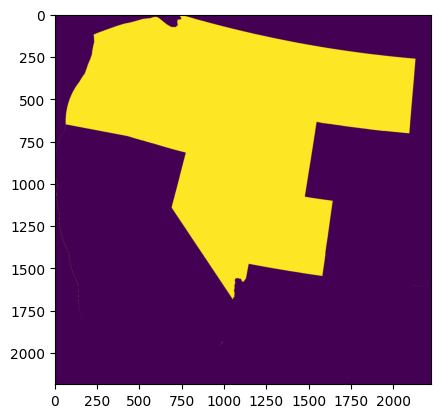

<Axes: >

In [23]:
from rasterio.plot import show
show(lmp_array == -99)

In [19]:
gdf_feature_subset.region_name.unique()

array(['arizona', 'california', 'colorado', 'new_mexico', 'wyoming'],
      dtype=object)

In [17]:
cfdf[cfdf.tech_simple.str.contains('Wind')]

,region_name,sited_year,scenario,tech_simple,capacity_factor_fraction
6,arizona,2020,rcp45cooler_ssp5,Wind (Onshore),0.358954
13,arizona,2020,rcp45hotter_ssp5,Wind (Onshore),0.359597
17,arizona,2020,rcp85cooler_ssp3,Wind (Onshore),0.361785
21,arizona,2020,rcp85cooler_ssp5,Wind (Onshore),0.360231
25,arizona,2020,rcp85hotter_ssp3,Wind (Onshore),0.361981
...,...,...,...,...,...
1803,wyoming,2055,rcp45hotter_ssp5,Wind (Onshore),0.422112
1806,wyoming,2055,rcp85cooler_ssp3,Wind (Onshore),0.439623
1809,wyoming,2055,rcp85cooler_ssp5,Wind (Onshore),0.449798
1812,wyoming,2055,rcp85hotter_ssp3,Wind (Onshore),0.439346
